# Customer Churn Predictor — EDA & Feature Selection
### Introduction to Data Science | GitHub API

This notebook covers the full analytical pipeline:
1. Data collection & churn labeling
2. Exploratory Data Analysis (EDA)
3. Feature generation
4. **All 4 feature selection methods** with comparison table
5. Model training & saving

In [1]:
import sys
sys.path.append('../app')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scraper import fetch_github_users, label_churn, GITHUB_USERNAMES
from features import generate_features, get_feature_names

print('Libraries loaded OK')

Libraries loaded OK


## Step 1 — Fetch Data from GitHub API

In [2]:
# Fetch from API (or load from cache if already collected)
import os

RAW_PATH = '../data/raw/github_users_labeled.csv'

if os.path.exists(RAW_PATH):
    print('Loading cached data...')
    df_raw = pd.read_csv(RAW_PATH)
else:
    print('Fetching from GitHub API...')
    df_raw = fetch_github_users(GITHUB_USERNAMES)
    df_raw = label_churn(df_raw, days_threshold=180)
    os.makedirs('../data/raw', exist_ok=True)
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw)} records')

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Fetching from GitHub API...
Fetching 700 GitHub user profiles...
  [1/700] torvalds: OK
  [2/700] karpathy: OK
  [3/700] openai: OK
  [4/700] microsoft: OK
  [5/700] claude: OK
  [6/700] gustavoguanabara: OK
  [7/700] yyx990803: OK
  [8/700] deepseek-ai: OK
  [9/700] gaearon: OK
  [10/700] peng-zhihui: OK
  [11/700] ruanyf: OK
  [12/700] sindresorhus: OK
  [13/700] github: OK
  [14/700] bradtraversy: OK
  [15/700] google: OK
  [16/700] anthropics: OK
  [17/700] JakeWharton: OK
  [18/700] huggingface: OK
  [19/700] TheAlgorithms: OK
  [20/700] lucidrains: OK
  [21/700] rafaballerini: OK
  [22/700] hiteshchoudhary: OK
  [23/700] IDouble: OK
  [24/700] tj: OK
  [25/700] steipete: OK
  [26/700] EpicGames: OK
  [27/700] addyosmani: OK
  [28/700] ThePrimeagen: OK
  [29/700] modelcontextprotocol: OK
  [30/700] geohot: OK
  [31/700] getify: OK
  [32/700] krishnaik06: OK
  [33/700] CodeWithHarry: OK
  [34/700] 3b1b: OK
  [35/700] nilbuild: OK
  [36/700] filipedeschamps: OK
  [37/700] Microsoft-

,username,public_repos,public_gists,followers,following,created_at,updated_at,hireable,site_admin,last_active,days_inactive,churned
0,torvalds,12,1,307501,0,2011-09-03T15:26:22Z,2026-06-02T05:33:59Z,None,False,2026-06-02 05:33:59+00:00,13,0
1,karpathy,63,13,199735,8,2010-04-10T17:55:32Z,2026-03-09T20:56:54Z,None,False,2026-03-09 20:56:54+00:00,97,0
2,openai,255,0,123769,0,2015-10-03T19:34:05Z,2026-04-17T23:58:17Z,None,False,2026-04-17 23:58:17+00:00,58,0
3,microsoft,8015,0,122747,0,2013-12-10T19:06:48Z,2025-06-06T20:30:56Z,None,False,2025-06-06 20:30:56+00:00,373,1
4,claude,0,0,119460,0,2009-05-07T00:15:43Z,2026-01-02T00:03:45Z,None,False,2026-01-02 00:03:45+00:00,164,0


## Step 2 — EDA & Churn Label Check

Churn label distribution:
churned
0    595
1    105
Name: count, dtype: int64

Churn rate: 15.0%


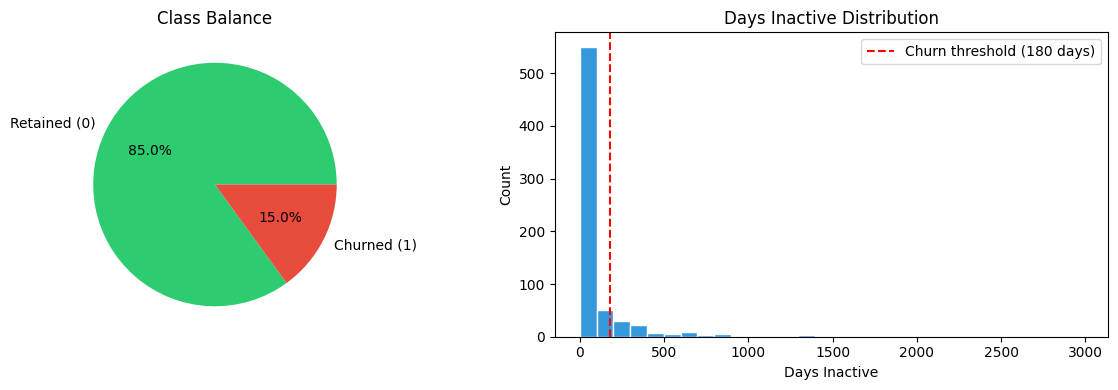

In [3]:
# Check class balance
print('Churn label distribution:')
print(df_raw['churned'].value_counts())
print(f"\nChurn rate: {df_raw['churned'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance pie
df_raw['churned'].value_counts().plot(
    kind='pie', ax=axes[0], labels=['Retained (0)', 'Churned (1)'],
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Class Balance')
axes[0].set_ylabel('')

# Days inactive distribution
axes[1].hist(df_raw['days_inactive'], bins=30, color='#3498db', edgecolor='white')
axes[1].axvline(180, color='red', linestyle='--', label='Churn threshold (180 days)')
axes[1].set_xlabel('Days Inactive')
axes[1].set_ylabel('Count')
axes[1].set_title('Days Inactive Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/raw/eda_class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 3 — Feature Generation

**Why each feature matters:**
- `days_inactive`: Primary recency signal — users who haven't acted recently are most likely to churn
- `account_age_years`: Context for other features; older accounts with no activity are different from new ones
- `follower_ratio`: Social engagement quality — passive followers with no community tend to disengage
- `repos_per_year`: Productivity rate normalized by account age — more comparable than raw counts
- `total_public_contributions`: Overall volume of public work (repos + gists)
- `social_size`: Total network connections — larger networks correlate with retention
- `has_no_repos`: Binary flag — zero repos is qualitatively different from low activity
- `has_no_followers`: Binary flag — socially isolated users have higher churn risk

In [4]:
df = generate_features(df_raw)
print(f'Features generated: {df.shape}')
df.describe()

Features generated: (700, 8)


,account_age_years,follower_ratio,repos_per_year,total_public_contributions,social_size,has_no_repos,has_no_followers,churned
count,700.000000,700.000000,700.000000,700.000000,7.000000e+02,700.0000,700.0,700.000000
mean,11.778398,8090.849568,24.187394,303.190000,2.604187e+04,0.0200,0.0,0.150000
std,4.399863,17507.810126,129.827658,1144.450259,7.038362e+04,0.1401,0.0,0.357327
min,0.328542,0.010193,0.000000,0.000000,7.281000e+03,0.0000,0.0,0.000000
25%,8.997947,210.121622,3.320243,38.000000,9.333500e+03,0.0000,0.0,0.000000
50%,12.464066,2738.476190,7.682345,108.000000,1.242700e+04,0.0000,0.0,0.000000
75%,15.206708,10457.000000,17.966432,248.500000,1.956125e+04,0.0000,0.0,0.000000
max,18.652977,307501.000000,3105.013288,24103.000000,1.147106e+06,1.0000,0.0,1.000000


In [5]:
# Check for missing values
print('Missing values per feature:')
print(df.isnull().sum())

# Drop any rows with NaN
df = df.dropna()
print(f'\nRows after dropna: {len(df)}')

Missing values per feature:
account_age_years             0
follower_ratio                0
repos_per_year                0
total_public_contributions    0
social_size                   0
has_no_repos                  0
has_no_followers              0
churned                       0
dtype: int64

Rows after dropna: 700


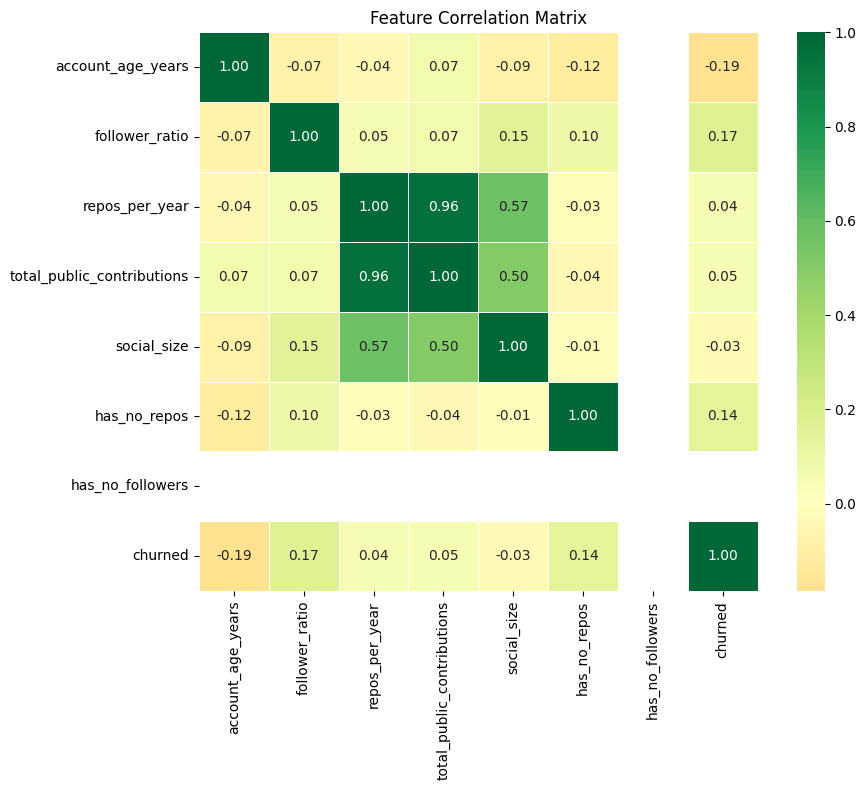

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/raw/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 4 — Feature Selection: All 4 Methods

We now apply all 4 methods and compare their rankings.

In [7]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = get_feature_names()
X = df[FEATURE_COLS]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')
print(f'Features: {FEATURE_COLS}')

Training set: (560, 7), Test set: (140, 7)
Features: ['account_age_years', 'follower_ratio', 'repos_per_year', 'total_public_contributions', 'social_size', 'has_no_repos', 'has_no_followers']


### Method 1 — Filter Methods
Filter methods evaluate features **independently** of any model. Fast, good for removing obviously useless features first.

=== Variance Threshold ===
Kept:    ['account_age_years', 'follower_ratio', 'repos_per_year', 'total_public_contributions', 'social_size', 'has_no_repos']
Dropped: ['has_no_followers']

=== ANOVA F-test (SelectKBest, top 5) ===
account_age_years             24.901634
follower_ratio                20.929433
has_no_repos                  13.960000
total_public_contributions     1.580319
repos_per_year                 1.234281
social_size                    0.590779
has_no_followers                    NaN
dtype: float64


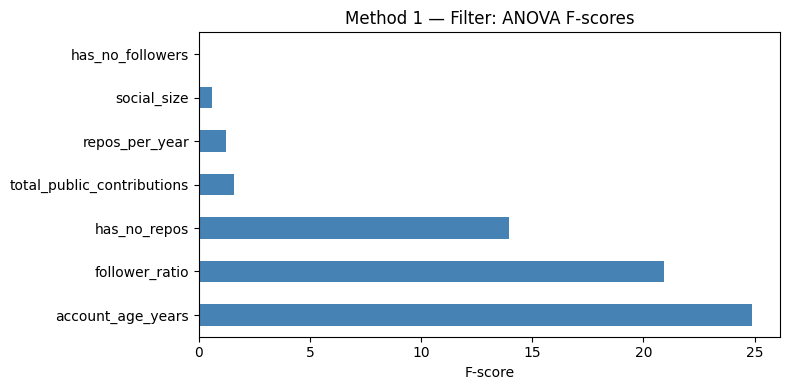

In [8]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# --- Variance Threshold ---
print('=== Variance Threshold ===')
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X)
kept_by_var = X.columns[sel_var.get_support()].tolist()
dropped_by_var = X.columns[~sel_var.get_support()].tolist()
print(f'Kept:    {kept_by_var}')
print(f'Dropped: {dropped_by_var}')

# --- ANOVA F-test (SelectKBest) ---
print('\n=== ANOVA F-test (SelectKBest, top 5) ===')
sel_kbest = SelectKBest(score_func=f_classif, k=5)
sel_kbest.fit(X, y)
filter_scores = pd.Series(
    sel_kbest.scores_, index=FEATURE_COLS
).sort_values(ascending=False)
print(filter_scores)

# Plot
filter_scores.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Method 1 — Filter: ANOVA F-scores')
plt.xlabel('F-score')
plt.tight_layout()
plt.savefig('../data/raw/method1_filter.png', dpi=100, bbox_inches='tight')
plt.show()

### Method 2 — Wrapper: Recursive Feature Elimination (RFE)
RFE uses a model to iteratively remove the weakest feature. More accurate than filters, but slower.

In [9]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

rfe_selected = X.columns[rfe.support_].tolist()
rfe_rankings = pd.Series(rfe.ranking_, index=FEATURE_COLS).sort_values()

print('=== RFE Results ===')
print(f'Selected features: {rfe_selected}')
print(f'\nAll rankings (1 = selected):')
print(rfe_rankings)

=== RFE Results ===
Selected features: ['account_age_years', 'follower_ratio', 'repos_per_year', 'social_size', 'has_no_repos']

All rankings (1 = selected):
account_age_years             1
follower_ratio                1
repos_per_year                1
social_size                   1
has_no_repos                  1
total_public_contributions    2
has_no_followers              3
dtype: int32


### Method 3 — Decision Tree Importance
A single Decision Tree scores features by Gini impurity reduction. Interpretable but noisy.

=== Decision Tree Feature Importances ===
follower_ratio                0.394578
repos_per_year                0.232011
account_age_years             0.155331
social_size                   0.113793
total_public_contributions    0.104287
has_no_repos                  0.000000
has_no_followers              0.000000
dtype: float64


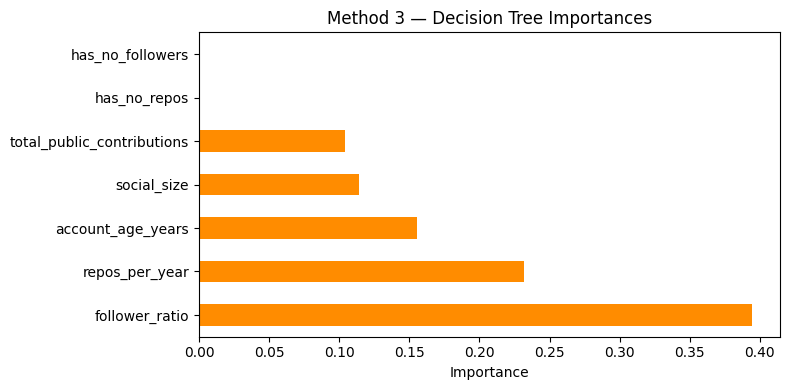

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

dt_importances = pd.Series(
    dt.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print('=== Decision Tree Feature Importances ===')
print(dt_importances)

dt_importances.plot(kind='barh', color='darkorange', figsize=(8, 4))
plt.title('Method 3 — Decision Tree Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/raw/method3_decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()

### Method 4 — Random Forest Importance
100 trees averaged — much more stable and reliable than a single Decision Tree.

=== Random Forest Feature Importances ===
follower_ratio                0.386651
account_age_years             0.210440
total_public_contributions    0.153018
repos_per_year                0.149420
social_size                   0.093598
has_no_repos                  0.006872
has_no_followers              0.000000
dtype: float64


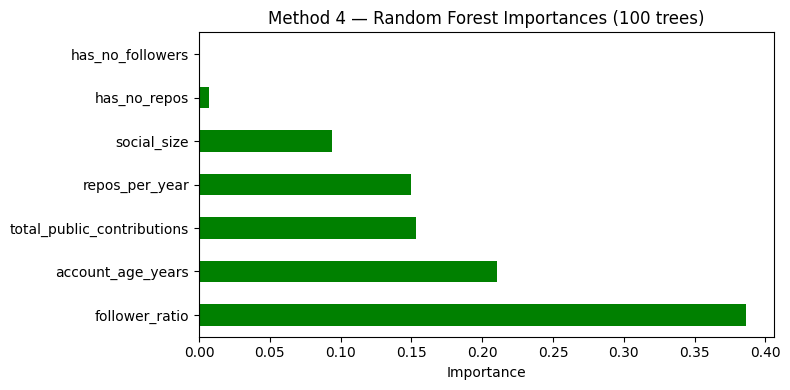

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

rf_importances = pd.Series(
    rf.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print('=== Random Forest Feature Importances ===')
print(rf_importances)

rf_importances.plot(kind='barh', color='green', figsize=(8, 4))
plt.title('Method 4 — Random Forest Importances (100 trees)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/raw/method4_random_forest.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary Comparison Table

This is the most important output — synthesizing all 4 methods into one table.

In [ ]:
# Build comparison table
filter_ranks = filter_scores.rank(ascending=False, na_option='bottom').fillna(len(FEATURE_COLS) + 1).astype(int)
dt_ranks     = dt_importances.rank(ascending=False, na_option='bottom').fillna(len(FEATURE_COLS) + 1).astype(int)
rf_ranks     = rf_importances.rank(ascending=False, na_option='bottom').fillna(len(FEATURE_COLS) + 1).astype(int)

comparison = pd.DataFrame({
    'Filter Rank':  filter_ranks,
    'RFE Selected': ['✅' if f in rfe_selected else '❌' for f in FEATURE_COLS],
    'DT Rank':      dt_ranks,
    'RF Rank':      rf_ranks,
}, index=FEATURE_COLS)

# Avg rank across the 3 numeric methods
comparison['Avg Rank'] = (
    comparison['Filter Rank'] + comparison['DT Rank'] + comparison['RF Rank']
) / 3

comparison = comparison.sort_values('Avg Rank')
comparison['Decision'] = comparison['Avg Rank'].apply(
    lambda r: '✅ Keep' if r <= 2.5 else ('⚠️ Optional' if r <= 4 else '❌ Drop')
)

print('=== FEATURE SELECTION COMPARISON TABLE ===')
print(comparison.to_string())
comparison['Decision'] = comparison['Avg Rank'].apply(
    lambda r: '✅ Keep' if r <= 2.5 else ('⚠️ Optional' if r <= 4 else '❌ Drop')
)

print('=== FEATURE SELECTION COMPARISON TABLE ===')
print(comparison.to_string())

=== FEATURE SELECTION COMPARISON TABLE ===
                            Filter Rank RFE Selected  DT Rank  RF Rank  Avg Rank     Decision
follower_ratio                        2            ✅        1        1  1.333333       ✅ Keep
account_age_years                     1            ✅        3        2  2.000000       ✅ Keep
repos_per_year                        5            ✅        2        4  3.666667  ⚠️ Optional
total_public_contributions            4            ❌        5        3  4.000000  ⚠️ Optional
social_size                           6            ✅        4        5  5.000000       ❌ Drop
has_no_repos                          3            ✅        6        6  5.000000       ❌ Drop
has_no_followers                      7            ❌        6        7  6.666667       ❌ Drop
=== FEATURE SELECTION COMPARISON TABLE ===
                            Filter Rank RFE Selected  DT Rank  RF Rank  Avg Rank     Decision
follower_ratio                        2            ✅        1       

## Model Training & Saving

Train the final model using the top 5 features from the comparison table and save to `app/model.pkl`.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import joblib

# Top 5 features from the comparison table
FINAL_FEATURES = [
    'follower_ratio',
    'repos_per_year',
    'account_age_years',
    'has_no_repos',
]

X_final       = df[FINAL_FEATURES]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

final_model = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    class_weight='balanced', random_state=42
)
final_model.fit(X_train_f, y_train_f)

y_pred = final_model.predict(X_test_f)
print('Test Set Classification Report:')
print(classification_report(y_test_f, y_pred))

cv = cross_val_score(final_model, X_final, y, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv.mean():.3f} ± {cv.std():.3f}')

# Save model to app/ directory
joblib.dump(final_model, '../app/model.pkl')
print('\nModel saved to ../app/model.pkl')